In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats 
import math 

# Data loading 

In [2]:
data_path = '/kaggle/input/datasets/himanshusinghal19/ragnarok-technology/Technology.csv'
df = pd.read_csv(data_path)
df.head(3)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021,MI,FT,Data Scientist,30400000,CLP,40038,CL,100,CL,L
1,2021,MI,FT,BI Data Analyst,11000000,HUF,36259,HU,50,US,L
2,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L


# Data overview 

In [3]:
def show_data_overview(df):
    print('\nSample data (first 5 rows): ')
    display(df.head(5))
    print("-"*50)
    print('\nInformation:')
    print(df.info())
    print("-"*50)
    print('\nThe number of duplicated rows:')
    print(df.duplicated().sum())
    print("-"*50)
    print('\nThe number of mising data per feature:')
    display(df.isna().sum().sort_values(ascending = False))

In [4]:
show_data_overview(df)


Sample data (first 5 rows): 


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021,MI,FT,Data Scientist,30400000,CLP,40038,CL,100,CL,L
1,2021,MI,FT,BI Data Analyst,11000000,HUF,36259,HU,50,US,L
2,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
3,2021,MI,FT,ML Engineer,8500000,JPY,77364,JP,50,JP,S
4,2022,SE,FT,Lead Machine Learning Engineer,7500000,INR,95386,IN,50,IN,L


--------------------------------------------------

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14838 entries, 0 to 14837
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           14838 non-null  int64 
 1   experience_level    14838 non-null  object
 2   employment_type     14838 non-null  object
 3   job_title           14838 non-null  object
 4   salary              14838 non-null  int64 
 5   salary_currency     14838 non-null  object
 6   salary_in_usd       14838 non-null  int64 
 7   employee_residence  14838 non-null  object
 8   remote_ratio        14838 non-null  int64 
 9   company_location    14838 non-null  object
 10  company_size        14838 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.2+ MB
None
--------------------------------------------------

The number of duplicated rows:
5711
--------------------------------------------------

The num

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

# EDA 

## Duplicated value 

In [8]:
def check_duplicates(df):
    n = len(df)
    n_duplicates = df.duplicated().sum()
    ratio_duplicates = n_duplicates/n
    duplicated_rows = df[df.duplicated(keep=False)]
    print("Number of duplicates: ",n_duplicates)
    print("Ratio (%): ",ratio_duplicates*100)
    print("Some duplicates:")
    display(duplicated_rows.head(5))
check_duplicates(df)

Number of duplicates:  5711
Ratio (%):  38.489014692007004
Some duplicates:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
70,2024,MI,FT,Machine Learning Scientist,750000,USD,750000,US,0,US,M
72,2024,MI,FT,Machine Learning Scientist,750000,USD,750000,US,0,US,M
82,2024,MI,FT,Research Engineer,720000,USD,720000,US,0,US,M
84,2024,MI,FT,Research Engineer,720000,USD,720000,US,0,US,M
92,2024,SE,FT,Machine Learning Engineer,550000,USD,550000,US,0,US,M


- Duplicate count: 5,711 records.

- Reason: The dataset does not have a primary key. As this dataset consists of job descriptions, frequent duplication is expected and quite normal.

- Recommendation: Given that up to 38% of the sample data is duplicated, the data source and collection process should be carefully reviewed

## Univariate Analysis

### Numeric features 

In [16]:
num_features = df.select_dtypes(include =['number']).columns.tolist()
print(num_features)

['work_year', 'salary', 'salary_in_usd', 'remote_ratio']


In [17]:
num_features.remove('salary')

In [14]:
def analyze_numeric_features(df,num_features):
    print(f"There are {len(num_features)} features: {num_features}" )
    print("-"*50)
    for feature in num_features:
        print(f'\nFeature: {feature}')
        
        print(f"\nStatistics:")
        print(df[feature].describe())
        
        print(f"\nVisualization:")
        fig,ax = plt.subplots(1,2,figsize=(10,5))
        sns.histplot(data = df,x = feature, kde = True, ax = ax[0])
        ax[0].set_title(f'Distribution of {feature}')
        sns.boxplot(data=df, x = feature,ax = ax[1])
        ax[1].set_title(f'Boxplot of {feature}')
        plt.tight_layout()
        plt.show()
        print("-"*50)
    

In [28]:
def analyze_outliers (df,num_features,threshold_z = 3):
    summary_data = []
    n = len(df)
    for col in num_features:
        data = df[col]  
        
        # IQR
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5*IQR 
        upper_bound = Q3 + 1.5*IQR
        n_iqr = ((data < lower_bound) | (data > upper_bound)).sum()
        pct_iqr = (n_iqr / n) * 100
        
        # zscore 
        if data.std() == 0:
            n_zscore = 0
            pct_zscore = 0.0
        else:
            z_scores = np.abs(stats.zscore(data))
            n_zscore = (z_scores > threshold_z).sum()
            pct_zscore = (n_zscore / n) * 100

        summary_data.append({
            'Feature': col,
            'IQR_Outlier_Count': n_iqr,
            'IQR_Outlier_Pct': round(pct_iqr, 2),
            'Z_Outlier_Count': n_zscore,
            'Z_Outlier_Pct': round(pct_zscore, 2)
        })
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values(by='IQR_Outlier_Count', ascending=False).reset_index(drop=True)
    
    return summary_df

There are 3 features: ['work_year', 'salary_in_usd', 'remote_ratio']
--------------------------------------------------

Feature: work_year

Statistics:
count    14838.000000
mean      2023.138900
std          0.700799
min       2020.000000
25%       2023.000000
50%       2023.000000
75%       2024.000000
max       2024.000000
Name: work_year, dtype: float64

Visualization:


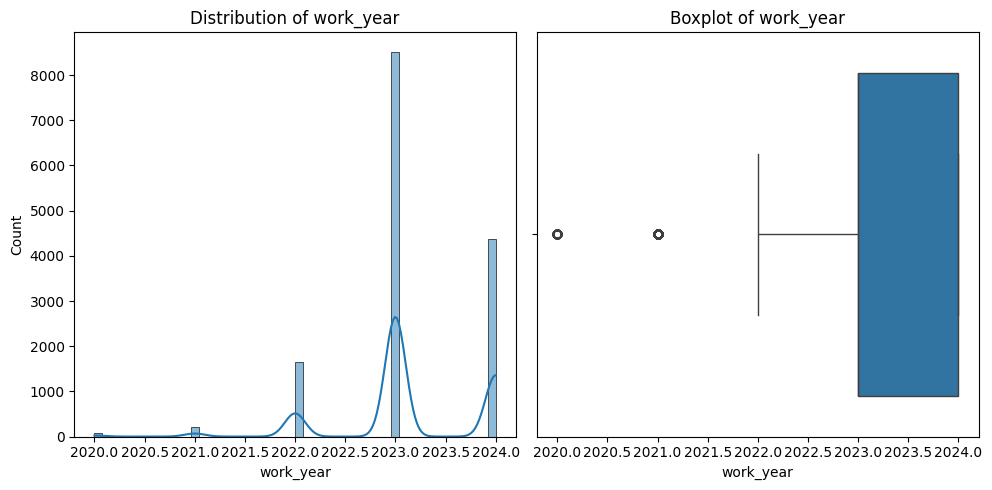

--------------------------------------------------

Feature: salary_in_usd

Statistics:
count     14838.000000
mean     149874.718763
std       69009.181349
min       15000.000000
25%      102000.000000
50%      141300.000000
75%      185900.000000
max      800000.000000
Name: salary_in_usd, dtype: float64

Visualization:


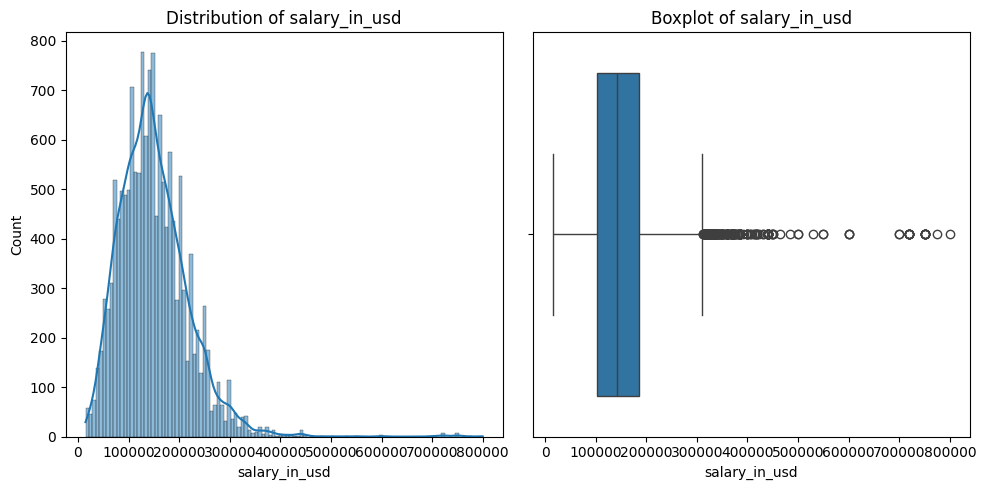

--------------------------------------------------

Feature: remote_ratio

Statistics:
count    14838.000000
mean        32.760480
std         46.488278
min          0.000000
25%          0.000000
50%          0.000000
75%        100.000000
max        100.000000
Name: remote_ratio, dtype: float64

Visualization:


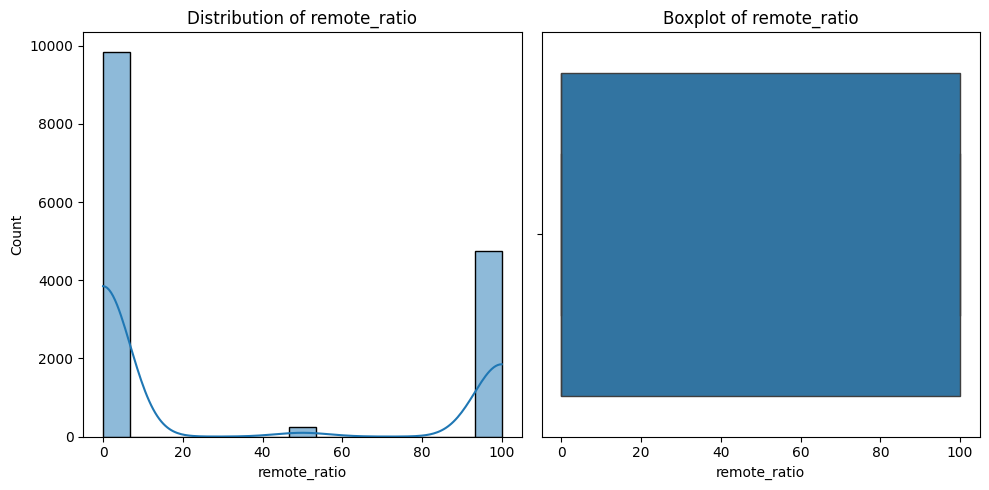

--------------------------------------------------


In [18]:
analyze_numeric_features(df,num_features)

In [32]:
df['remote_ratio'].value_counts()

remote_ratio
0      9853
100    4737
50      248
Name: count, dtype: int64

In [29]:
analyze_outliers(df,num_features)

,Feature,IQR_Outlier_Count,IQR_Outlier_Pct,Z_Outlier_Count,Z_Outlier_Pct
0,work_year,293,1.97,293,1.97
1,salary_in_usd,270,1.82,129,0.87
2,remote_ratio,0,0.00,0,0.00


In [33]:
num_features.remove('remote_ratio')
print(num_features)

['work_year', 'salary_in_usd']


1. Overall
* **Outliers:** Quite few, taking up a very small part compared to the whole data, around **2%** of the data.

---

2. Column Detail

* **`salary`**
  * Due to not having the same currency.
  * No statistical meaning when looking overall.
  * Skip, do not consider.

* **`work_year`**
  * Data is concentrated from 2022 to 2024.
  * Very few data points in 2020, 2021.
  * There are many reasons: the collected dataset is skewed, or this industry group in 2020, 2021 did not have much market demand.
  * The column is more like a categorical column so calculating outliers here does not have much statistical meaning.
  * However, when researching, we can set weights for the year: the closer the year, the clearer it shows market demand compared to the present.

* **`salary_in_usd`**
  * Data is right-skewed at the right tail.
  * Outliers: A few salaries are very high compared to the market.
  * Mostly concentrated in the range (0, 300,000), outliers can reach up to 800,000.
  * 2.5 times higher compared to the normal group.
  * This is a small group of people with super high income compared to the overall.

* **`remote_ratio`**
  * Categorical group: analyze later (0, 50, 100).
  * This is actually a categorical variable rather than a number.
  * Has no statistical meaning.

###  Categorical 

In [35]:
cat_features = df.select_dtypes(include = ['object']).columns.tolist()
cat_features.append('remote_ratio')
print(cat_features)

['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size', 'remote_ratio']


In [40]:
def analyze_categorical_features(df,cat_features):
    print(f"There are {len(cat_features)} features: {cat_features}" )
    print("-"*50)
    for feature in cat_features:
        print(f'\nFeature: {feature}')
        print(f"Statistics:")
        summary = df[feature].value_counts().to_frame('Count')
        summary['Percentage'] = (df[feature].value_counts(normalize = True)*100).round(2)
        print(summary)
        print(f"Visualization:")
        plt.figure(figsize = (10,6))
        if len(summary.index) < 10 :
            sns.countplot(data=df, x= feature, order = summary.index)
        else:
            sns.countplot(data=df, y= feature, order = summary.index)
        plt.tight_layout()
        plt.show()
    

There are 8 features: ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size', 'remote_ratio']
--------------------------------------------------

Feature: experience_level
Statistics:
                  Count  Percentage
experience_level                   
SE                 9696       65.35
MI                 3553       23.95
EN                 1148        7.74
EX                  441        2.97
Visualization:


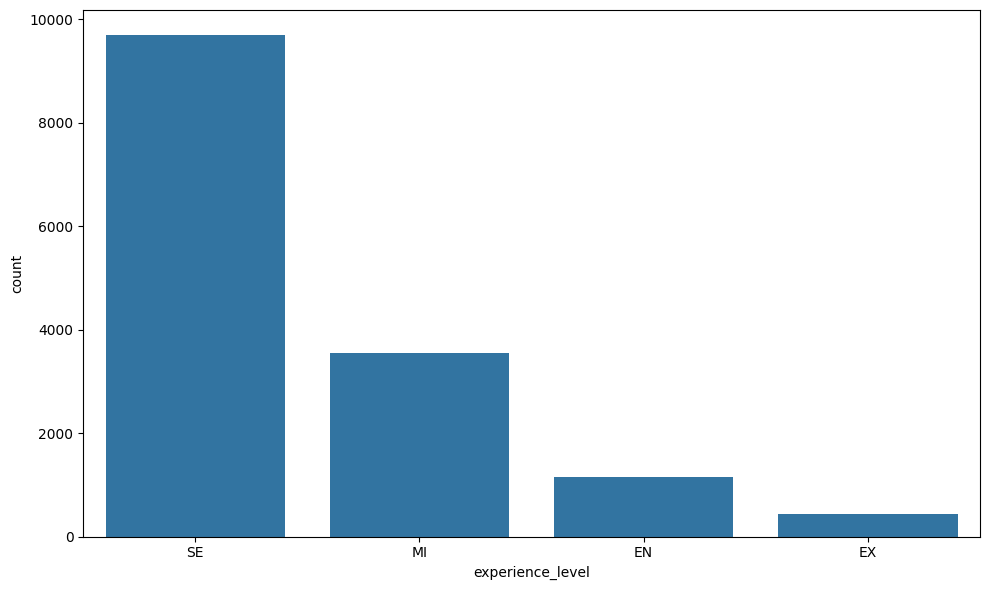


Feature: employment_type
Statistics:
                 Count  Percentage
employment_type                   
FT               14772       99.56
PT                  27        0.18
CT                  26        0.18
FL                  13        0.09
Visualization:


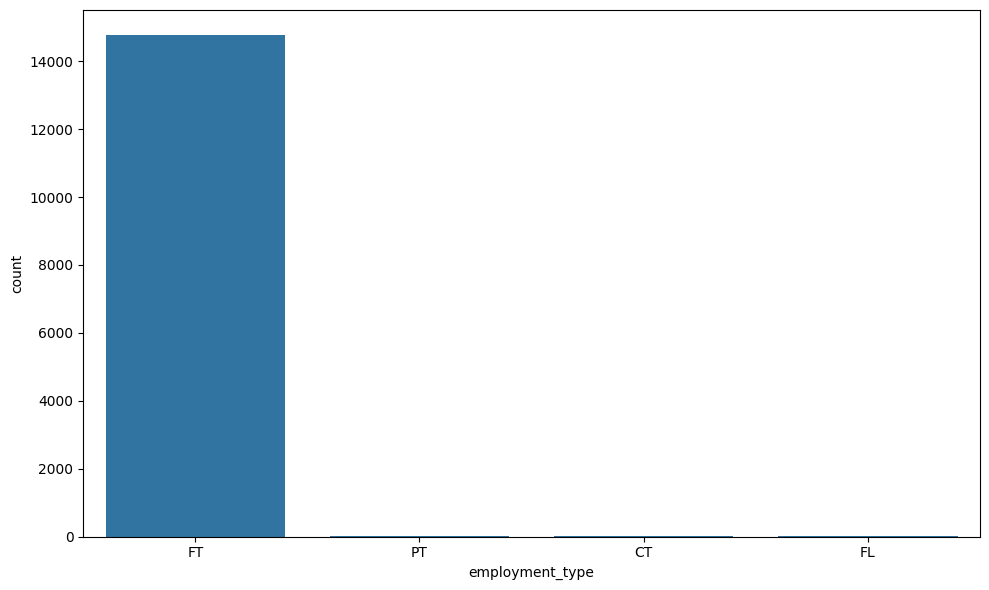


Feature: job_title
Statistics:
                               Count  Percentage
job_title                                       
Data Engineer                   3162       21.31
Data Scientist                  3015       20.32
Data Analyst                    2189       14.75
Machine Learning Engineer       1542       10.39
Research Scientist               475        3.20
...                              ...         ...
Power BI Developer                 1        0.01
BI Data Engineer                   1        0.01
Sales Data Analyst                 1        0.01
Quantitative Research Analyst      1        0.01
CRM Data Analyst                   1        0.01

[153 rows x 2 columns]
Visualization:


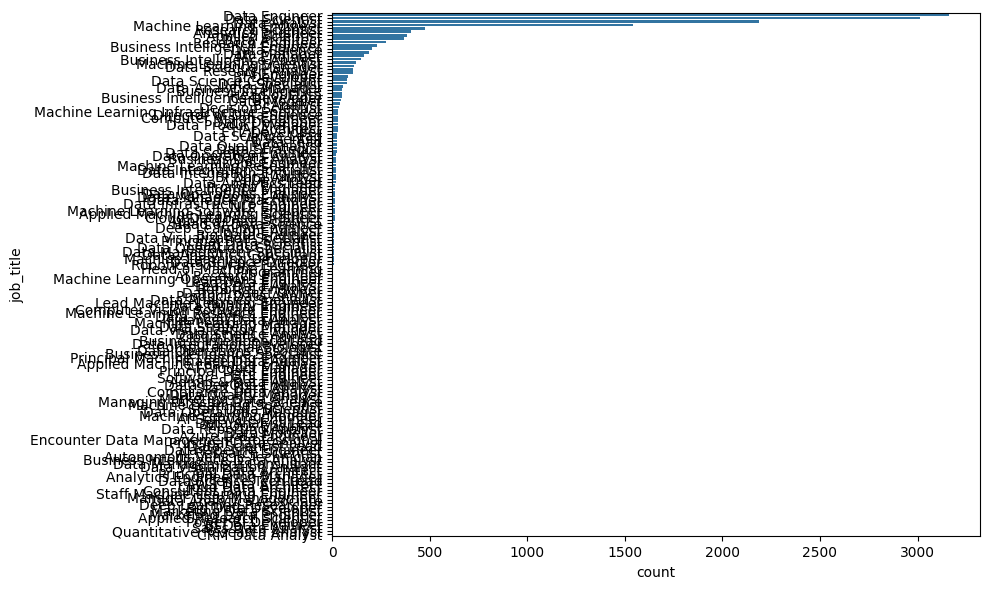


Feature: salary_currency
Statistics:
                 Count  Percentage
salary_currency                   
USD              13682       92.21
GBP                567        3.82
EUR                424        2.86
INR                 53        0.36
CAD                 51        0.34
AUD                 12        0.08
CHF                  8        0.05
PLN                  7        0.05
SGD                  6        0.04
BRL                  4        0.03
JPY                  4        0.03
HUF                  3        0.02
TRY                  3        0.02
DKK                  3        0.02
THB                  2        0.01
NOK                  2        0.01
CLP                  1        0.01
ILS                  1        0.01
ZAR                  1        0.01
HKD                  1        0.01
PHP                  1        0.01
MXN                  1        0.01
NZD                  1        0.01
Visualization:


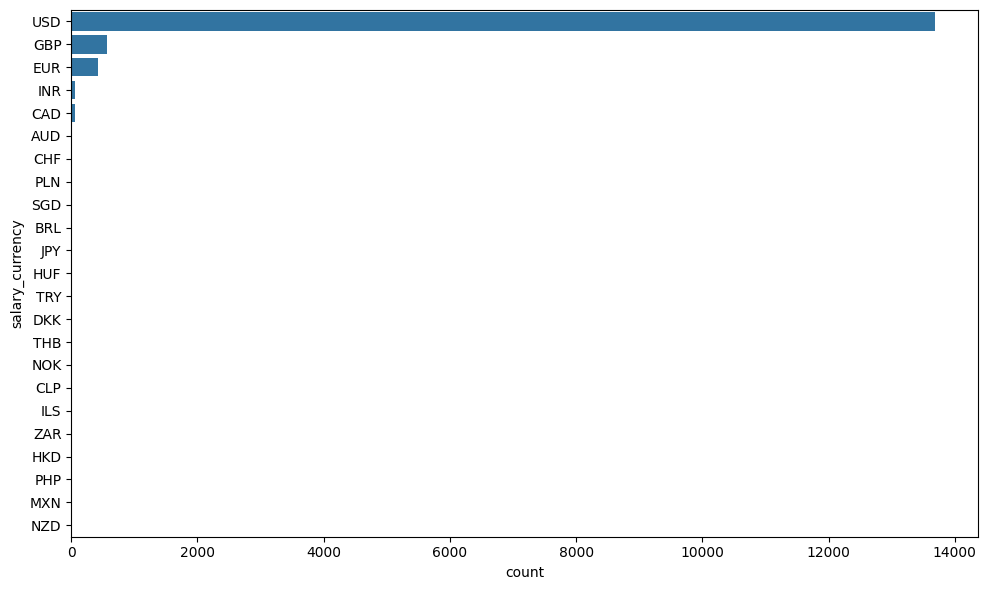


Feature: employee_residence
Statistics:
                    Count  Percentage
employee_residence                   
US                  12926       87.11
GB                    647        4.36
CA                    390        2.63
ES                    131        0.88
DE                     91        0.61
...                   ...         ...
RS                      1        0.01
CR                      1        0.01
HN                      1        0.01
EC                      1        0.01
ID                      1        0.01

[88 rows x 2 columns]
Visualization:


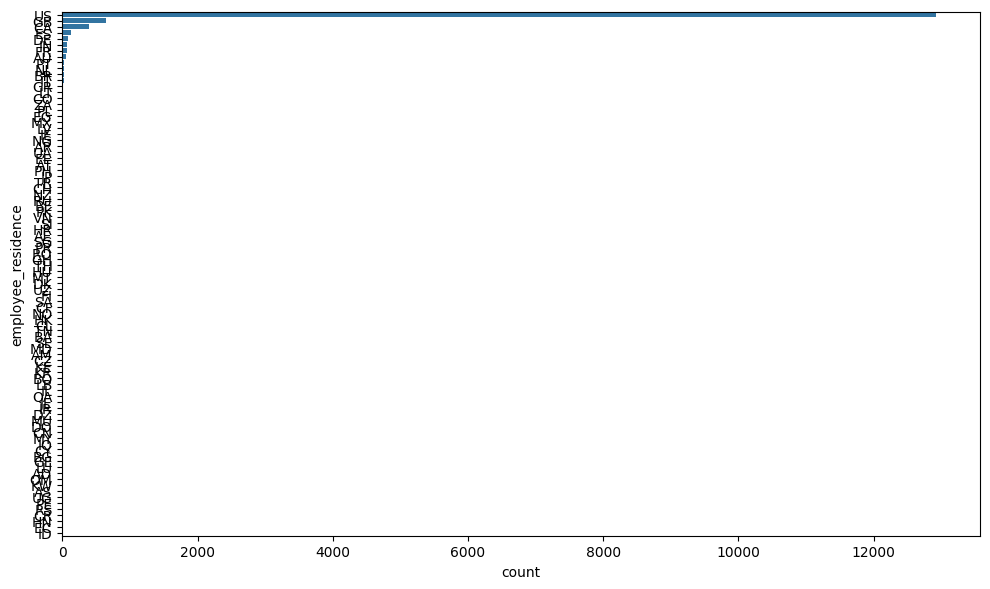


Feature: company_location
Statistics:
                  Count  Percentage
company_location                   
US                12975       87.44
GB                  655        4.41
CA                  392        2.64
ES                  127        0.86
DE                   98        0.66
...                 ...         ...
BS                    1        0.01
MY                    1        0.01
HN                    1        0.01
MD                    1        0.01
EC                    1        0.01

[77 rows x 2 columns]
Visualization:


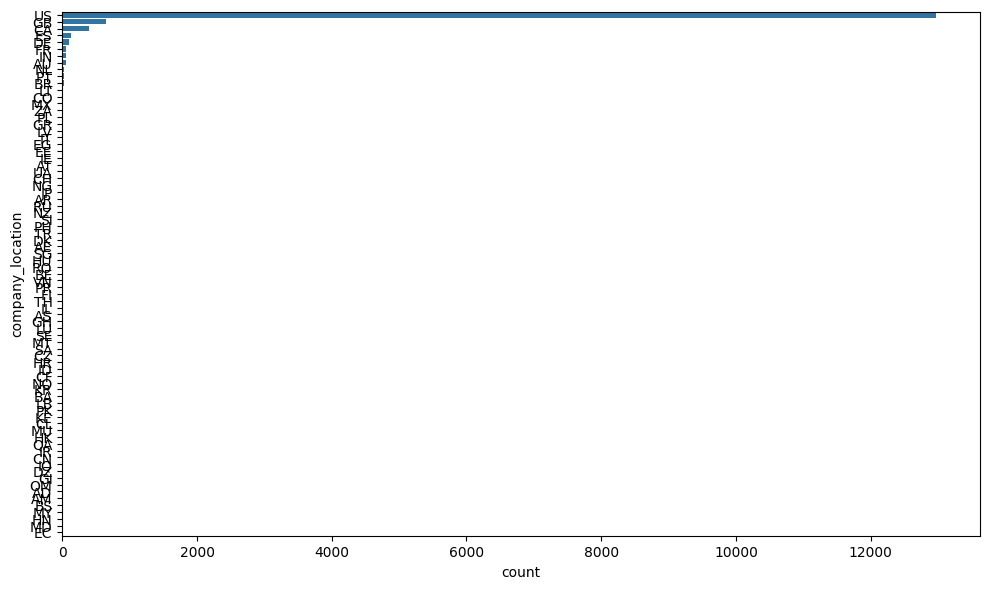


Feature: company_size
Statistics:
              Count  Percentage
company_size                   
M             13674       92.16
L               983        6.62
S               181        1.22
Visualization:


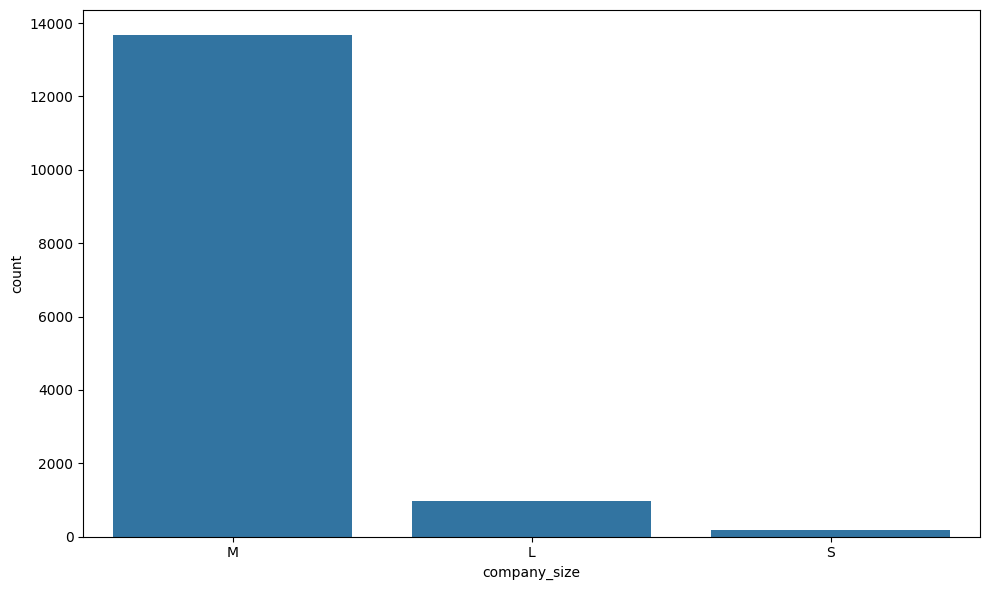


Feature: remote_ratio
Statistics:
              Count  Percentage
remote_ratio                   
0              9853       66.40
100            4737       31.92
50              248        1.67
Visualization:


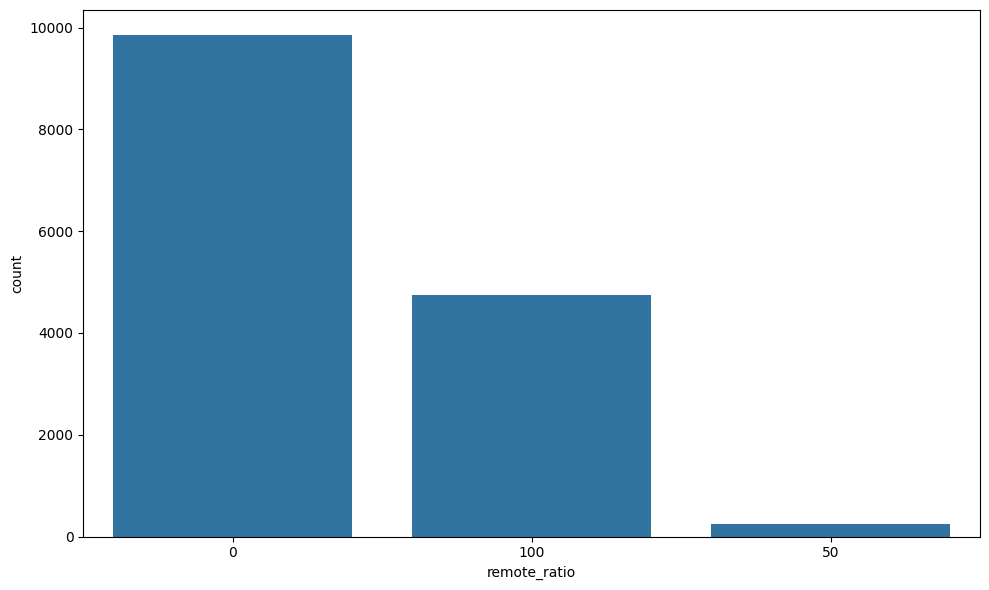

In [41]:
analyze_categorical_features(df,cat_features)

 1. `experience_level`
* Consists of 4 categories: `SE`, `MI`, `EN`, `EX`.
* Mapping order: `EN` < `MI` < `SE` < `EX` (Note: `SE` stands for Senior-level).

| Code | Full Name | Common Name | Estimated Experience | Description & Role |
| :---: | :--- | :--- | :---: | :--- |
| **EN** | **Entry-level** | Junior / Fresher | 0 - 2 years | Just starting out. |
| **MI** | **Mid-level** | Intermediate / Associate | 2 - 5 years | Mid-level. |
| **SE** | **Senior-level** | Senior / Expert | 5 - 10 years | Advanced. |
| **EX** | **Executive-level** | Director / VP / C-Level | > 10 years | Leadership / Executive. |

**Conclusion**
* The majority (over 60%) are concentrated at the Senior-level. The lowest is EX at around 3%, while Entry-level accounts for only about 8%.
* The low percentage of EX is easy to understand: companies do not need a large number of people in executive roles.
* The market currently demands people who can work independently and immediately, primarily focusing on Senior-level professionals.
* People at the Entry-level have very few choices, making the competition at the Entry-level significantly much fiercer.
---
2. `employment_type`
* Consists of 4 categories: `FT`, `PT`, `CT`, `FL`.

| Code | Full Name | Characteristics | Percentage (%) |
| :---: | :--- | :--- | :---: |
| **FT** | Full-time | Permanent employee | 99.56 |
| **PT** | Part-time | Reduced hours | 0.18 |
| **CT** | Contract | Project-based / Fixed-term | 0.18 |
| **FL** | Freelance | Independent worker | 0.09 |

**Conclusion**
* Almost all job postings require full-time employment (99.56%).
* The remaining types (part-time, contract, freelance) are minimal, with a combined total of less than 0.5%.

---

3. `company_size`
* Consists of 3 categories: `S`, `M`, `L` (`S` < `M` < `L`).
* **Distribution:** Medium-sized companies (`M`) dominate the majority at **92.16%**, followed by large companies (`L`) at **6.62%**, and small companies (`S`) accounting for only **1.22%**.

---

4. `job_title`
* Highly diverse, featuring up to 153 different categories.
* **Top roles with high weight:**
  * Data Engineer: **21.31%**
  * Data Scientist: **20.32%**
  * Data Analyst: **14.75%**
  * Machine Learning Engineer: **10.39%**
* The remaining groups each account for under 10% (specifically averaging around 3.2%, with many niche groups dropping to about 0.01%).
* **Action:** Will attempt to group them into broader categories such as Analyst, Scientist, Data Engineer, and AI Engineer.

---

5. `salary_currency`, `company_location`, & `employee_residence`
* **`salary_currency`:** Includes 23 types, predominantly **USD (92.21%)**, followed by GBP (British Pound) and EUR (Euro).
* **`company_location`:** Spans 77 locations, heavily dominated by the US, followed by the UK and Canada (with smaller percentages).
* **`employee_residence`:** Spans 88 locations, again heavily concentrated in the US, UK, and Canada.
* Most remaining classification groups account for less than 1%.

**Conclusion**
* The volume of jobs in other countries is very small compared to the overall total or the US market.
* The main reason salaries are predominantly paid in USD is that both companies and employees are primarily located in the US or countries using that currency, followed by Europe and the UK (as supported by `company_location` and `employee_residence`).
* **Hypotheses:**
  * The actual job market demand for data roles is genuinely massive in the US compared to most other countries.
  * Alternatively, the data collection process itself suffered from a bias, leading to an over-concentration on the US market.

---

6. `remote_ratio`
* **0:** Onsite – accounts for the largest share.
* **50:** Hybrid – relatively low.
* **100:** Fully remote – moderate share.
* Companies tend to prefer hiring for onsite work, offering relatively few opportunities for remote work and limited hybrid arrangements for candidates.

In [74]:
location_features = ['company_location','employee_residence']
job = ['job_title']
selected_cat_features = ['experience_level', 'employment_type', 'company_size', 'remote_ratio']

## Bivariate Analysis 

### Numeric features 

In [47]:
def analyze_correlation(df, num_vars):
    plt.figure(figsize=(8, 6))
    corr = df[num_vars].corr()
    sns.heatmap(corr, annot=True)
    plt.title('Correalation matrix', y=1.05)
    plt.show()

    print(num_vars)
    sns.pairplot(df[num_vars], kind='scatter', diag_kind='kde', height=3)
    plt.show()


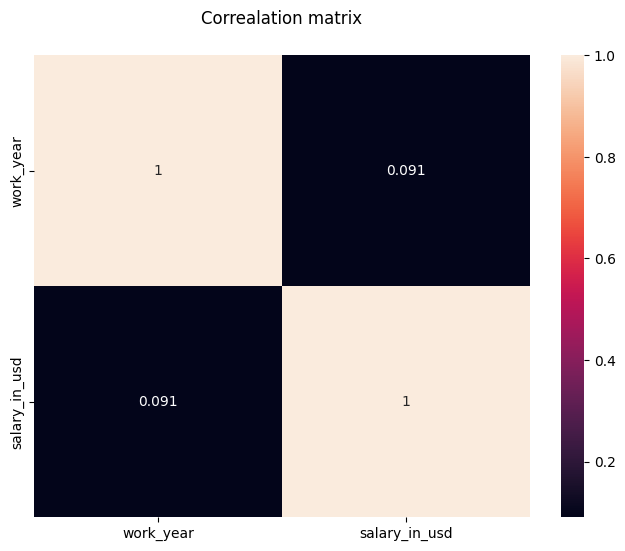

['work_year', 'salary_in_usd']


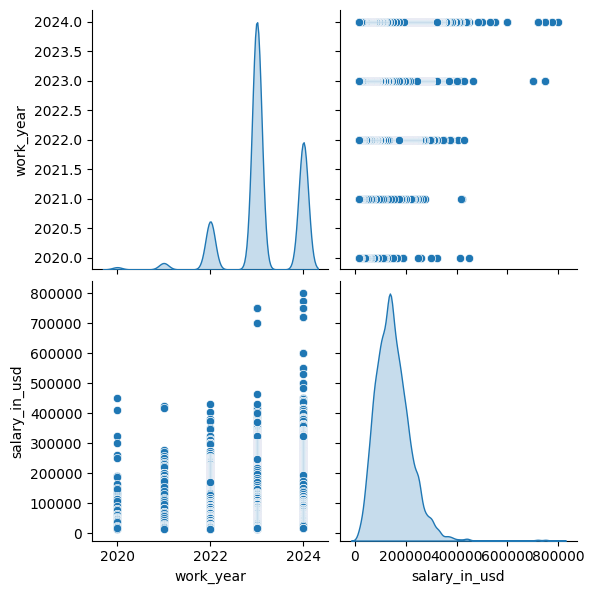

In [48]:
analyze_correlation(df,num_features)

### Categorical features 

In [72]:
def analyze_categorical_vs_target(df, cat_cols, target='salary_in_usd'):
    n_cols = len(cat_cols)
    
    fig, axes = plt.subplots(n_cols, 1, figsize=(10,6*n_cols))
    
    if n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(cat_cols):
       
        sorted_order = df.groupby(col)[target].median().sort_values().index
        
        sns.boxplot(
            data=df, 
            x=col, 
            y=target, 
            order=sorted_order, 
            hue=col,        
            legend=False,    
            ax=axes[i], 
            palette='viridis'
        )
        
        axes[i].set_title(f'{target} vs {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target)
    for j in range(n_cols, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


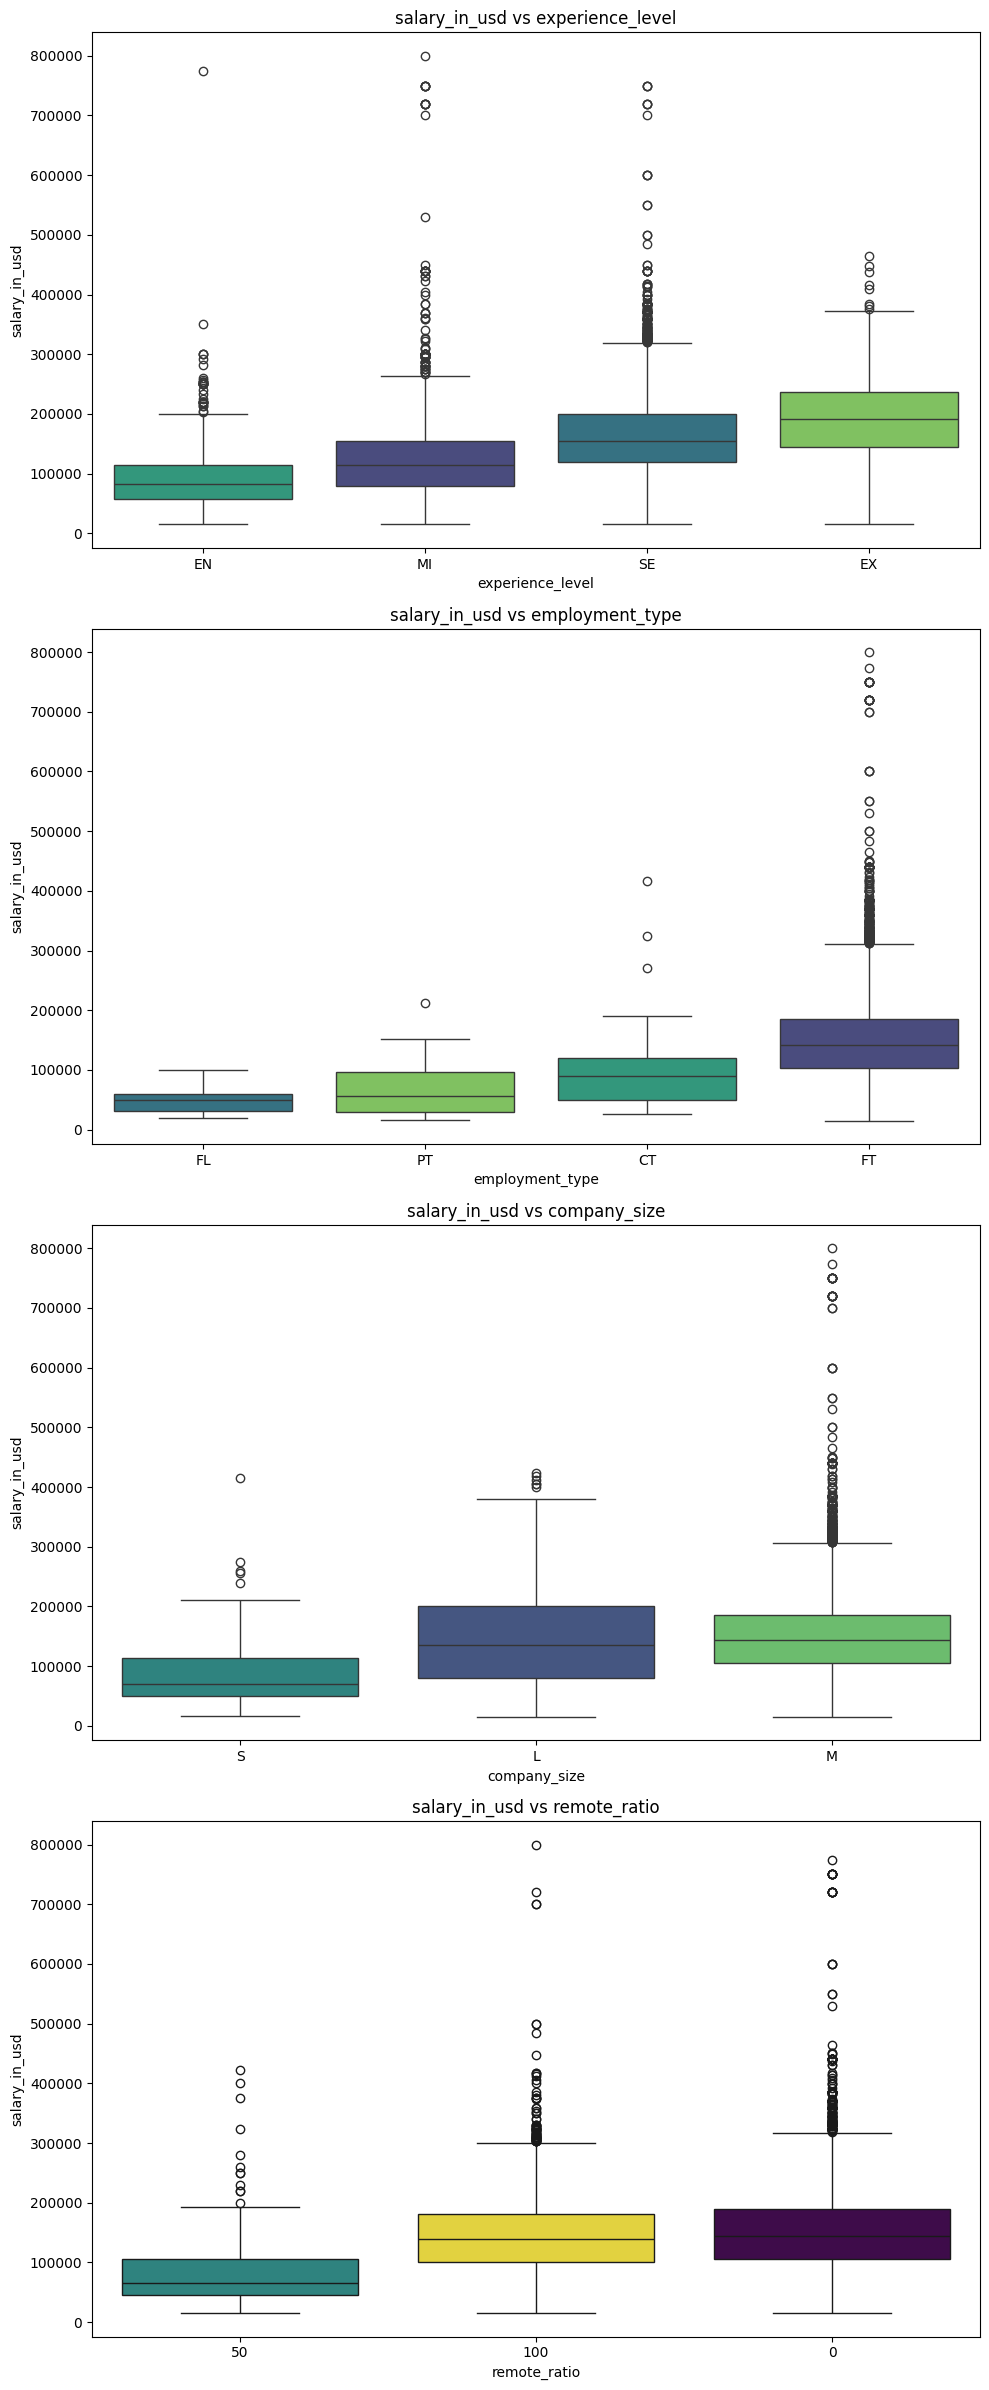

In [73]:
analyze_categorical_vs_target(df, selected_cat_features, target='salary_in_usd')

1. Salary Impact by Experience
* **Box heights increase progressively:** `EN` < `MI` < `SE` < `EX`, which aligns with common logic.
* **Salary gap:** The difference between levels is approximately **40,000 USD**.
* All groups contain outliers, indicating internal salary variance.
* The variance in the `MI` and `SE` groups is even larger than in the `EX` group.
* Notably, the 800,000 USD outlier falls into the `MI` group rather than higher-experience groups like `SE` or `EX`.

---

2. Salary by Employment Type
* **Full-time (FT):** Dominates overwhelmingly in stability and contains almost all high-value outliers (including the 800k USD point).
* **Other types (PT, FL, CT):** Salaries are very low (expected due to reduced working hours), with **Freelance** being the lowest.

---

3. Salary by Company Size
* **Small (S):** Offers the lowest salaries.
* **Medium (M) vs. Large (L):**
  * The median salary for Medium companies (`M`) is slightly higher than Large companies (`L`) by about **10,000 USD**.
  * Medium companies also exhibit higher and more extreme outliers (reaching the 800k mark).
* This indicates that mid-sized companies are willing to pay very generous salaries to compete for top talent against industry giants.
---
4. Salary by Remote Ratio
* Salaries for **100% remote** and **onsite** roles tend to be higher compared to **hybrid** roles (50).

## Multivariate Analysis

### The Impact of Experience Level and Company Size on Salary

In [75]:
def analyze_salary_exp_vs_size(df):
    plt.figure(figsize=(14, 8))

    exp_order = ['EN', 'MI', 'SE', 'EX']
    size_order = ['S', 'M', 'L'] 

    sns.boxplot(
        data=df,
        x='experience_level',
        y='salary_in_usd',
        hue='company_size',      
        order=exp_order,
        hue_order=size_order,
        palette='viridis'
    )

    plt.title('In-depth Analysis: Salary vs Experience Level vs Company Size', fontsize=14)
    plt.xlabel('Experience Level')
    plt.ylabel('Salary (USD)')
    plt.legend(title='Company Size')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    plt.show()

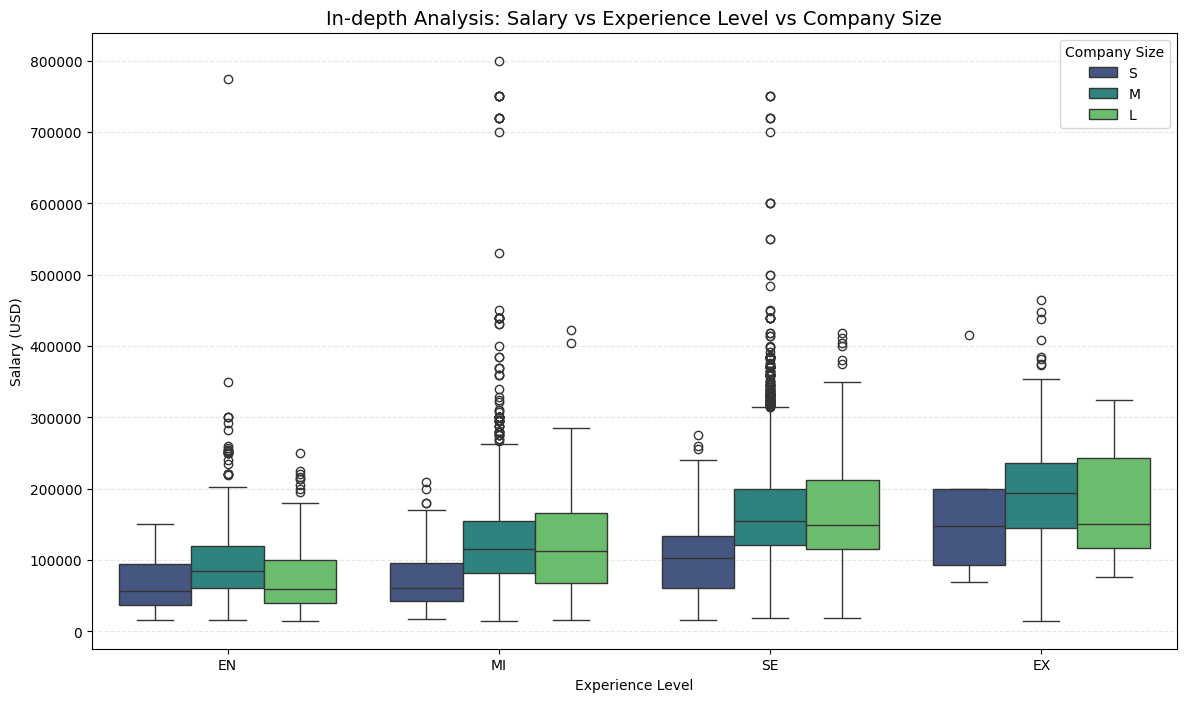

In [76]:
analyze_salary_exp_vs_size(df)

5. Salary Comparison by Experience and Company Size 
* **At `MI` and `SE` experience levels:** The median salaries at Medium (`M`) companies are higher (the highest) and have much larger salary variance compared to Large (`L`) companies.
* **At the `EX` experience level:** Medium (`M`) companies still maintain the highest median salary.
* **At the `EN` experience level:** Medium (`M`) companies also remain the highest.

**Conclusion**
* This indicates that Medium (`M`) companies offer more generous compensation and provide easier access to higher salary tiers for candidates with the same level of experience compared to Large (`L`) companies.

### Impact of Geographic Location on Salary (US vs. Non-US)

--- MEDIAN SALARY COMPARISON ---
location_group
US        148000.0
Non-US     79981.0
Name: salary_in_usd, dtype: float64

=> Working in the US pays 1.85 times higher (68,019 USD) than the rest of the world!


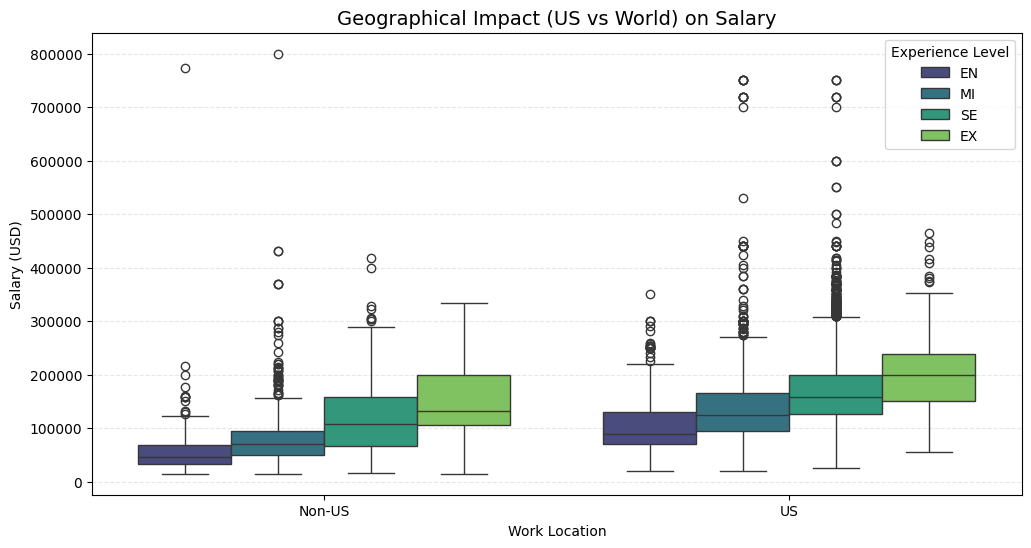

In [77]:
def analyze_us_vs_world(df):
    df['location_group'] = df['company_location'].apply(lambda x: 'US' if x == 'US' else 'Non-US')

    print("--- MEDIAN SALARY COMPARISON ---")
    median_stats = df.groupby('location_group')['salary_in_usd'].median().sort_values(ascending=False)
    print(median_stats)

    diff = median_stats['US'] - median_stats['Non-US']
    ratio = median_stats['US'] / median_stats['Non-US']
    print(f"\n=> Working in the US pays {ratio:.2f} times higher ({diff:,.0f} USD) than the rest of the world!")

  
    plt.figure(figsize=(12, 6))

    order_exp = ['EN', 'MI', 'SE', 'EX']

    sns.boxplot(
        data=df,
        x='location_group',
        y='salary_in_usd',
        hue='experience_level',
        hue_order=order_exp,
        palette='viridis'
    )

    plt.title('Geographical Impact (US vs World) on Salary', fontsize=14)
    plt.xlabel('Work Location')
    plt.ylabel('Salary (USD)')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title='Experience Level')

    plt.show()

analyze_us_vs_world(df)

### Exploring more  in job_title 

In [85]:
from sklearn.feature_extraction.text import CountVectorizer

In [109]:
vectorizer = CountVectorizer(ngram_range=(1,2))
matrix = vectorizer.fit_transform(df['job_title'])
titles = vectorizer.get_feature_names_out()
[title for title in titles if len(title.split())==2 ]


['admin data',
 'ai architect',
 'ai developer',
 'ai engineer',
 'ai product',
 'ai programmer',
 'ai research',
 'ai scientist',
 'ai software',
 'analyst lead',
 'analytics associate',
 'analytics consultant',
 'analytics engineer',
 'analytics engineering',
 'analytics lead',
 'analytics manager',
 'analytics specialist',
 'applied data',
 'applied machine',
 'applied research',
 'applied scientist',
 'autonomous vehicle',
 'aws data',
 'azure data',
 'bi analyst',
 'bi data',
 'bi developer',
 'big data',
 'business data',
 'business intelligence',
 'cloud data',
 'cloud database',
 'compliance data',
 'computational biologist',
 'computer vision',
 'consultant data',
 'crm data',
 'data analyst',
 'data analytics',
 'data architect',
 'data developer',
 'data devops',
 'data engineer',
 'data infrastructure',
 'data integration',
 'data lead',
 'data management',
 'data manager',
 'data modeler',
 'data modeller',
 'data operations',
 'data pipeline',
 'data product',
 'data qual

In [113]:
frequency = matrix.sum(axis = 0).A1
summary = pd.DataFrame({
    'title':titles,
    'fre':frequency
})
summary = summary[summary['title'].str.count(' ') == 1]
summary.sort_values(by =['fre'], ascending = False).head(20)

,title,fre
63,data engineer,3195
77,data scientist,3053
58,data analyst,2266
140,machine learning,1796
129,learning engineer,1566
76,data science,523
43,business intelligence,502
200,research scientist,478
16,analytics engineer,408
25,applied scientist,383


In [101]:
!pip install wordcloud

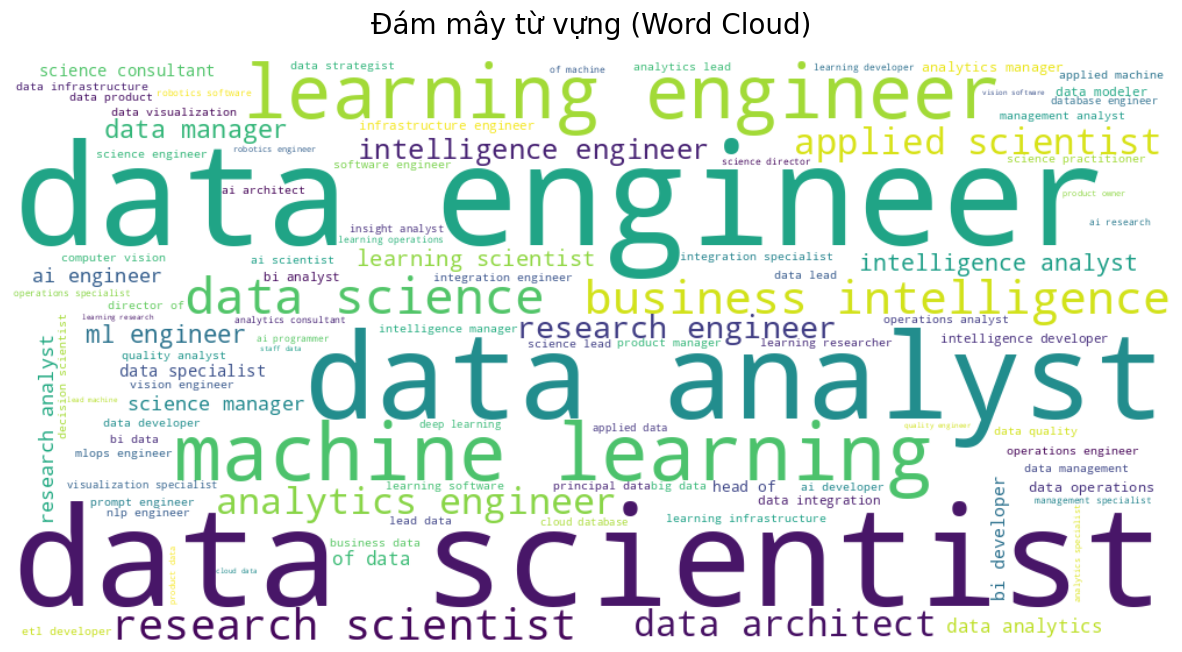

In [111]:
from wordcloud import WordCloud

freq_dict = dict(zip(summary['title'], summary['fre']))

wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white',
    colormap='viridis',       
    max_words=100      
).generate_from_frequencies(freq_dict)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Tắt trục tọa độ x, y
plt.title("Đám mây từ vựng (Word Cloud)", fontsize=20, pad=20)
plt.show()

# Summary 

### 1. Data Processing & Cleaning Strategy
* **Dataset Shape:** 14,838 rows and 11 columns.
* **Temporal Distribution:** Heavily concentrated from 2022 to 2024, with very few records in 2020 and 2021.
* **`salary` column:** Can be dropped since `salary_in_usd` and currency columns are already available.
* **`remote_ratio` column:** Can be treated as a categorical variable since it only contains specific percentage values (e.g., 0, 50, 100).
* **Duplicates:** High duplication rate (~38%); the data source should be re-verified.
* **Missing Values:** No missing data found.
* **Ordinal Columns:** Experience and company size have inherent order, making them suitable for ordinal mapping during modeling.
* **Outliers:** Primarily found in `salary_in_usd` (right-skewed due to a minority of ultra-high earners), which is a normal characteristic for salary data.
* **Categorical Columns:** Features like `job_title`, `company_location`, `employee_residence`, and `currency` have many unique classes, but only a few dominate while the rest account for less than 1% each. 
  * **Action:** Group them into broader, more general categories.

---

### 2. Salary Analysis & Influencing Factors
* **Non-influential Factors:** `work_year` and `remote_ratio` do not show a clear impact on salary levels.
* **Categorical Factors:**
  * **Experience Level:** Clearly impacts salary—more experience equals higher pay. However, the largest salary variance and prominent outliers appear in the `MI` and `SE` groups rather than `EX` as typically expected.
  * **Company Size:** Small (`S`) companies tend to pay lower salaries compared to Medium (`M`) and Large (`L`) companies across the same experience levels.
  * **Employment Type:** Full-time (`FT`) pays the highest (likely due to working hours and commitment level), while Freelance (`FL`) pays the lowest.
    * *Note:* The data is heavily imbalanced, with over 90% categorized as Full-time, so this statistic may be biased.
* **Cross-Analysis (Experience, Company Size, & Salary):**
  * **Medium (`M`) Companies:** Pay the highest salaries across all experience levels.
  * At the `MI` and `SE` experience levels, Medium (`M`) companies tend to offer higher salaries than Large (`L`) companies, along with massive variance, meaning a much higher potential to reach top-tier salaries compared to large corporations.
* **Geographical Location:** Salaries in the US are significantly higher than the rest of the world across all experience levels. This could either reflect true market dynamics or data collection bias toward the US market.

---

### 3. Key Takeaways & Recommendations

#### a. Characteristics of High-Paying Jobs
* **Location:** US-based (subject to potential data bias).
* **Experience:** Middle or Senior level.
* **Company Size:** Medium-sized companies.

#### b. Where Should Entry-Level Candidates Apply?
* **Location:** US market.
* **Company Size:** Medium-sized companies.
* **Job Roles:** High-demand roles still revolve around core tracks such as Data Engineer, Data Analyst, Data Scientist, or AI-related fields like Machine Learning Engineer.